# Car Insurance Dataset — Data Profiling
Explores the raw CSVs before migration: shape, missing values, distributions, and data quality issues.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['axes.facecolor'] = '#1a1f2e'
matplotlib.rcParams['figure.facecolor'] = '#0f1117'
matplotlib.rcParams['text.color'] = 'white'
matplotlib.rcParams['axes.labelcolor'] = 'white'
matplotlib.rcParams['xtick.color'] = 'white'
matplotlib.rcParams['ytick.color'] = 'white'

RAW = '../Data/raw'
PROCESSED = '../Data/processed'

## 1. Load Raw Files

In [2]:
policyholders = pd.read_csv(f'{RAW}/policyholders_raw.csv')
vehicles      = pd.read_csv(f'{RAW}/vehicles_raw.csv')
policies      = pd.read_csv(f'{RAW}/policies_raw.csv')
claims        = pd.read_csv(f'{RAW}/claims_raw.csv')
payments      = pd.read_csv(f'{RAW}/payments_raw.csv')

datasets = {
    'policyholders': policyholders,
    'vehicles':      vehicles,
    'policies':      policies,
    'claims':        claims,
    'payments':      payments,
}

print('Dataset shapes:')
for name, df in datasets.items():
    print(f'  {name:20s} → {df.shape[0]:,} rows  x  {df.shape[1]} columns')

Dataset shapes:
  policyholders        → 3,060 rows  x  12 columns
  vehicles             → 3,000 rows  x  11 columns
  policies             → 3,000 rows  x  11 columns
  claims               → 2,050 rows  x  10 columns
  payments             → 3,500 rows  x  8 columns


## 2. Missing Values Analysis

In [3]:
print('Missing values per dataset:\n')
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'  [{name}]')
        for col, cnt in missing.items():
            pct = cnt / len(df) * 100
            print(f'    {col:30s} {cnt:5d} ({pct:.1f}%)')
        print()

Missing values per dataset:

  [policyholders]
    full_name                        107 (3.5%)
    date_of_birth                     70 (2.3%)
    phone                            744 (24.3%)
    credit_score                     252 (8.2%)

  [vehicles]
    vehicle_value_usd                117 (3.9%)
    mileage                          151 (5.0%)

  [policies]
    deductible_usd                   283 (9.4%)

  [claims]
    settled_amount_usd              1664 (81.2%)
    description                      246 (12.0%)
    days_to_report                   110 (5.4%)

  [payments]
    payment_date                     153 (4.4%)



## 3. Data Quality Issues in Policyholders

In [4]:
print('Gender value counts (inconsistent casing):')
print(policyholders['gender'].value_counts().to_string())
print()
print('Marital status value counts:')
print(policyholders['marital_status'].value_counts().to_string())

Gender value counts (inconsistent casing):
gender
M         341
f         329
male      315
Female    307
m         303
Male      300
MALE      294
F         292
female    291
FEMALE    288

Marital status value counts:
marital_status
single      408
married     404
S           383
Single      383
Married     375
Divorced    372
Widowed     371
M           364


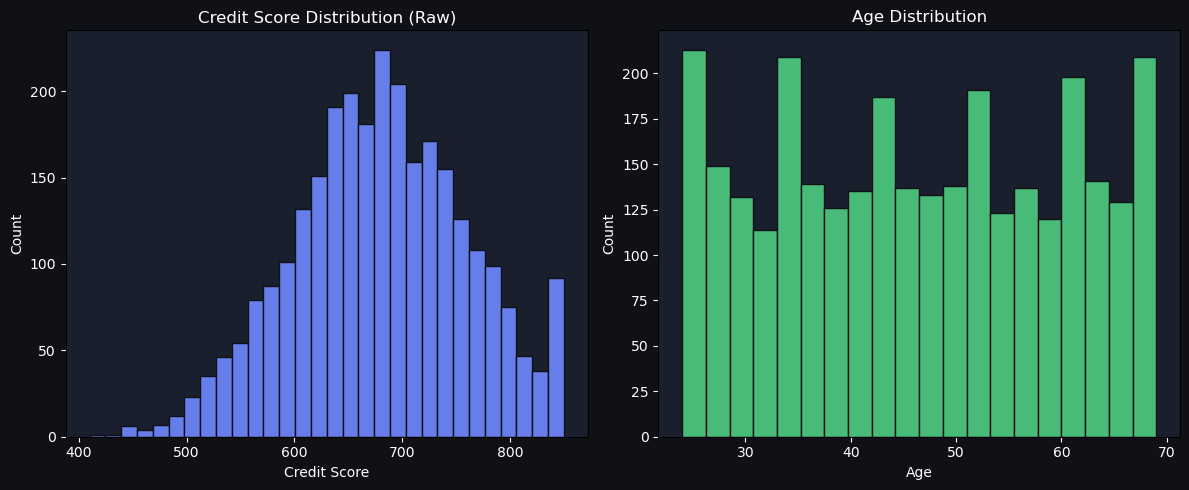

In [5]:
fig, axes = plt.subplots(1, 2)

credit_clean = pd.to_numeric(policyholders['credit_score'], errors='coerce').dropna()
axes[0].hist(credit_clean, bins=30, color='#667eea', edgecolor='#0f1117')
axes[0].set_title('Credit Score Distribution (Raw)')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')

age_clean = pd.to_numeric(policyholders['age'], errors='coerce').dropna()
axes[1].hist(age_clean, bins=20, color='#48bb78', edgecolor='#0f1117')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Data Quality Issues in Claims

In [6]:
print('Claim status values:')
print(claims['status'].value_counts().to_string())
print()
print('Fraud flag values:')
print(claims['is_fraud_flag'].value_counts().to_string())
print()
claim_amounts = pd.to_numeric(claims['claim_amount_usd'], errors='coerce')
print(f'Negative claim amounts: {(claim_amounts < 0).sum()}')
print(f'Zero claim amounts:     {(claim_amounts == 0).sum()}')

Claim status values:
status
Approved        452
Pending         421
Rejected        412
Settled         386
Under Review    379

Fraud flag values:
is_fraud_flag
No     1889
Yes     161

Negative claim amounts: 51
Zero claim amounts:     61


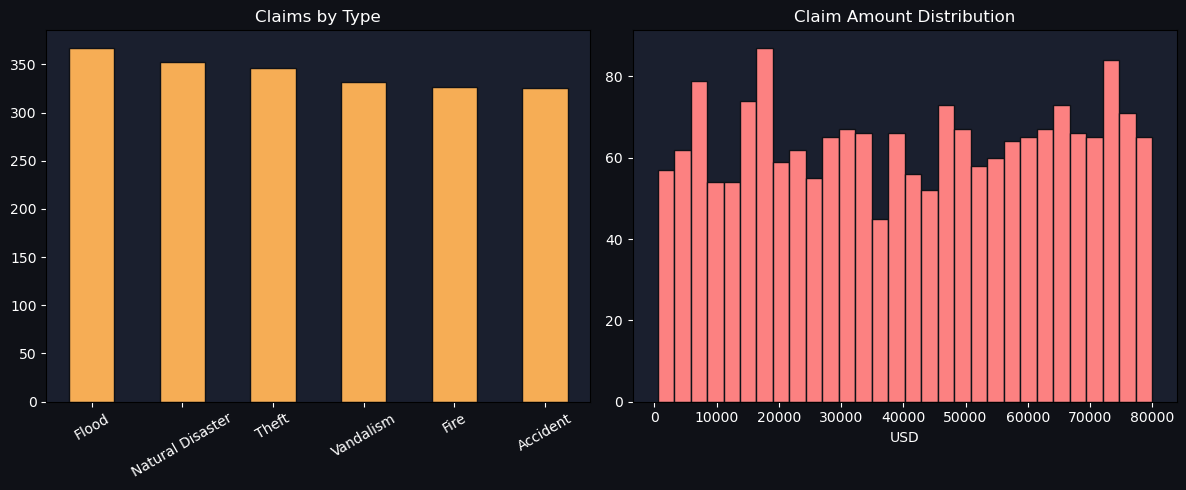

In [7]:
fig, axes = plt.subplots(1, 2)

claims['claim_type'].value_counts().plot(
    kind='bar', ax=axes[0], color='#f6ad55', edgecolor='#0f1117'
)
axes[0].set_title('Claims by Type')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

clean_amounts = claim_amounts[(claim_amounts > 0) & (claim_amounts < 80000)]
axes[1].hist(clean_amounts, bins=30, color='#fc8181', edgecolor='#0f1117')
axes[1].set_title('Claim Amount Distribution')
axes[1].set_xlabel('USD')

plt.tight_layout()
plt.show()

## 5. Date Format Inconsistencies

In [8]:
print('Sample claim dates (mixed formats):')
print(claims['claim_date'].head(10).to_string())
print()
print('Sample policy start dates:')
print(policies['start_date'].head(10).to_string())

Sample claim dates (mixed formats):
0    09 Sep 2023
1    01 Mar 2024
2     02/05/2021
3     01-18-2020
4     08-03-2022
5    13 Feb 2022
6     2024-10-25
7     2020-04-13
8     2023-01-15
9     2022-11-14

Sample policy start dates:
0     25/01/2021
1     2020-03-30
2    30 Sep 2022
3     03-11-2022
4     25/12/2019
5    24 Apr 2020
6     11-22-2024
7     04-26-2020
8    29 Nov 2020
9     17/06/2021


## 6. Vehicles — Currency String Mess

In [9]:
print('Vehicle value sample (mixed formats):')
print(vehicles['vehicle_value_usd'].head(10).to_string())
print()
print('Fuel type inconsistencies:')
print(vehicles['fuel_type'].value_counts().to_string())

Vehicle value sample (mixed formats):
0      16600.15
1    $68,642.11
2    $86,344.85
3      24918.04
4    $31,836.09
5      57639.39
6    $83,560.42
7    $17,756.82
8      40827.63
9    $19,111.01

Fuel type inconsistencies:
fuel_type
Diesel      403
Petrol      382
EV          382
petrol      379
Hybrid      372
DIESEL      364
hybrid      360
Electric    358


## 7. After Cleaning — Compare Processed Files

In [10]:
ph_clean = pd.read_csv(f'{PROCESSED}/policyholders.csv')
print('Gender after cleaning:')
print(ph_clean['gender'].value_counts().to_string())
print()
print('Credit score stats after cleaning:')
print(ph_clean['credit_score'].describe())

Gender after cleaning:
gender
Male       1186
Female     1130
Unknown     578

Credit score stats after cleaning:
count    2894.000000
mean      679.953697
std        77.383423
min       437.000000
25%       631.000000
50%       680.000000
75%       731.000000
max       850.000000
Name: credit_score, dtype: float64


In [11]:
print('Summary: Raw vs Processed row counts')
print(f'{"Table":20s} {"Raw":>8s} {"Processed":>10s} {"Dropped":>8s}')
print('-' * 50)
tables = ['policyholders','vehicles','policies','claims','payments']
for t in tables:
    raw_count  = pd.read_csv(f'{RAW}/{t}_raw.csv').shape[0]
    proc_count = pd.read_csv(f'{PROCESSED}/{t}.csv').shape[0]
    dropped    = raw_count - proc_count
    print(f'{t:20s} {raw_count:>8,} {proc_count:>10,} {dropped:>8,}')

Summary: Raw vs Processed row counts
Table                     Raw  Processed  Dropped
--------------------------------------------------
policyholders           3,060      2,894      166
vehicles                3,000      3,000        0
policies                3,000      3,000        0
claims                  2,050      2,000       50
payments                3,500      3,500        0
